In [14]:
from vitabel import Vitals
from pathlib import Path
import pyedflib
import pandas as pd

In [35]:
import bz2
import shutil

f_path = Path("../tests/data/sample_signals/test_generator_2.edf.bz2")
if f_path.suffix == ".bz2":
    unpacked_path = f_path.with_suffix("")
    with bz2.open(f_path, "rb") as src, open(unpacked_path, "wb") as dst:
        shutil.copyfileobj(src, dst)
    f_path = unpacked_path
case = Vitals()
case.add_edfplus(f_path)

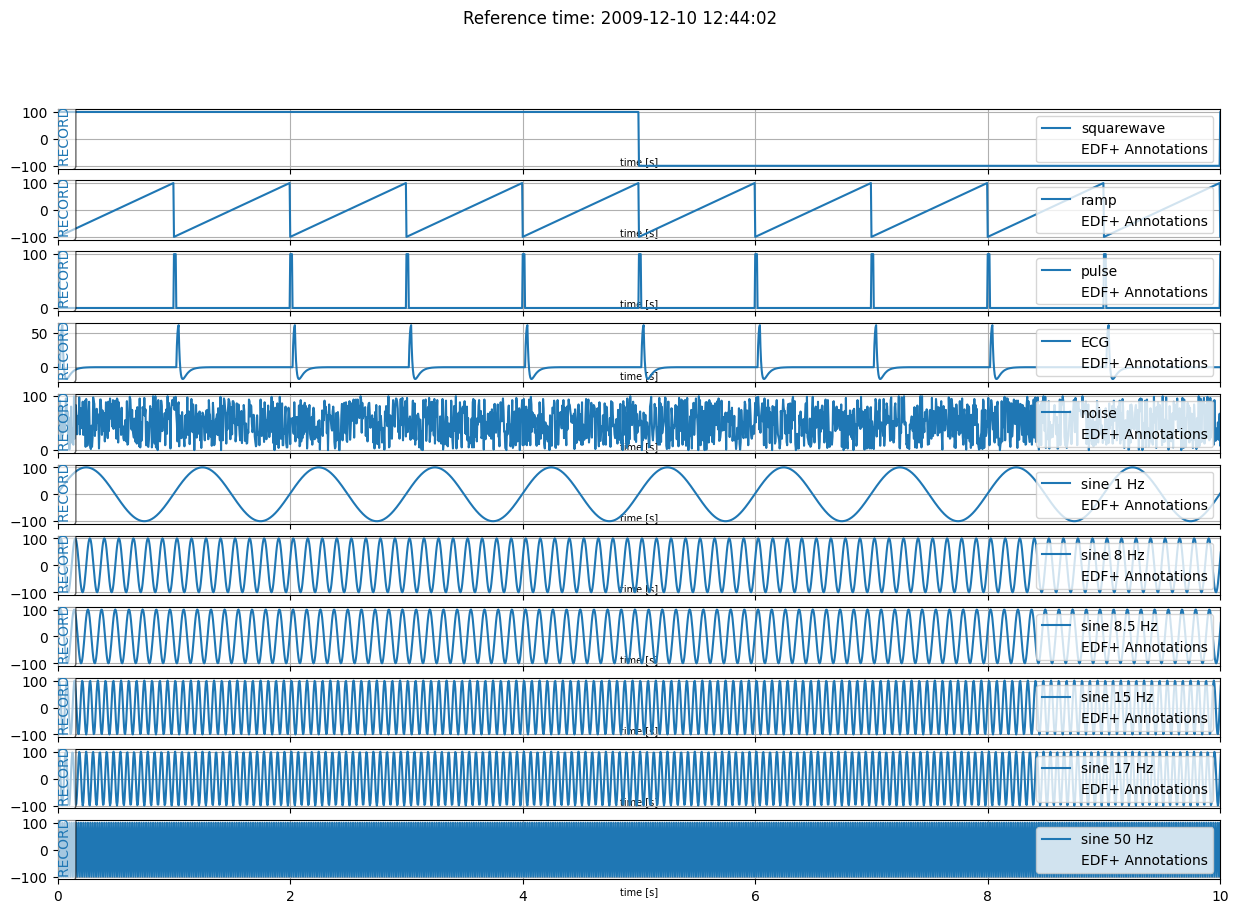

In [ ]:

plot, _ = case.plot(
    channels=[['squarewave'], 
              ['ramp'], 
              ['pulse'], 
              ['ECG'], 
              ['noise'], 
              ['sine 1 Hz'], 
              ['sine 8 Hz'], 
              ['sine 8.5 Hz'], 
              ['sine 15 Hz'], 
              ['sine 17 Hz'], 
              ['sine 50 Hz']],
    labels=[["EDF+ Annotations"],
            ["EDF+ Annotations"],
            ["EDF+ Annotations"],
            ["EDF+ Annotations"],
            ["EDF+ Annotations"],
            ["EDF+ Annotations"],
            ["EDF+ Annotations"],
            ["EDF+ Annotations"],
            ["EDF+ Annotations"],
            ["EDF+ Annotations"],
            ["EDF+ Annotations"]            
            ],
    start=case.rec_start(),
    stop=case.rec_start() + pd.Timedelta(seconds=10),
    subplots_kwargs={"sharex": True, "figsize": (15, 10)}
)


In [49]:
plot.savefig("test_edf.png", dpi=100)

In [51]:
f = pyedflib.EdfReader(str(f_path))

In [52]:
f.readAnnotations()

(array([  0., 600.]),
 array([-1., -1.]),
 array(['RECORD START', 'REC STOP'], dtype='<U12'))